In [1]:
!pip install -q google-generativeai

import google.generativeai as genai

API_KEY = "###"
genai.configure(api_key=API_KEY)

for model in genai.list_models():
    print(model.name)

models/chat-bison-001
models/text-bison-001
models/embedding-gecko-001
models/gemini-1.0-pro-latest
models/gemini-1.0-pro
models/gemini-pro
models/gemini-1.0-pro-001
models/gemini-1.0-pro-vision-latest
models/gemini-pro-vision
models/gemini-1.5-pro-latest
models/gemini-1.5-pro-001
models/gemini-1.5-pro-002
models/gemini-1.5-pro
models/gemini-1.5-flash-latest
models/gemini-1.5-flash-001
models/gemini-1.5-flash-001-tuning
models/gemini-1.5-flash
models/gemini-1.5-flash-002
models/gemini-1.5-flash-8b
models/gemini-1.5-flash-8b-001
models/gemini-1.5-flash-8b-latest
models/gemini-1.5-flash-8b-exp-0827
models/gemini-1.5-flash-8b-exp-0924
models/gemini-2.0-flash-exp
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-preview
models/gemini-2.0-flash-lite-preview-02-05
models/gemini-2.0-pro-exp
models/gemini-2.0-pro-exp-02-05
models/gemini-exp-1206
models/gemini-2.0-flash-thinking-exp-01-21
models/gemini-2.0-flash-thinking-exp
models/gemini-2.0-flash-thinking-exp-12

In [2]:
!pip install -q google-generativeai diffusers torch transformers Pillow IPython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.5 MB/s eta 0:00:00


In [5]:
model = genai.GenerativeModel("gemini-2.0-pro-exp")
prompt = "Tell me about american rednose pitbulls"
response = model.generate_content(prompt)
print("Generated Story:")
print(response.text)

Generated Story:
Let's dive into the world of the "American Red Nose Pitbull." It's important to understand the terminology and the realities surrounding this type of dog.

**1.  "Pitbull" Isn't a Single Breed:**

   The most crucial thing to understand is that "Pitbull" is *not* a specific breed.  It's a general term, a *type* of dog, encompassing several distinct breeds and mixes:

   *   **American Pit Bull Terrier (APBT):**  This is the breed most directly associated with the term "Red Nose." The APBT is recognized by the United Kennel Club (UKC) and the American Dog Breeders Association (ADBA), but *not* by the American Kennel Club (AKC).
   *   **American Staffordshire Terrier (AmStaff):**  The AKC recognizes this breed.  AmStaffs and APBTs share a very close ancestry, and some dogs are even dual-registered.  They're often virtually indistinguishable to the untrained eye.
   *   **Staffordshire Bull Terrier (Staffy):** A smaller, stockier breed from England, also recognized by th

Using device: cuda


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Generating image...


  0%|          | 0/20 [00:00<?, ?it/s]


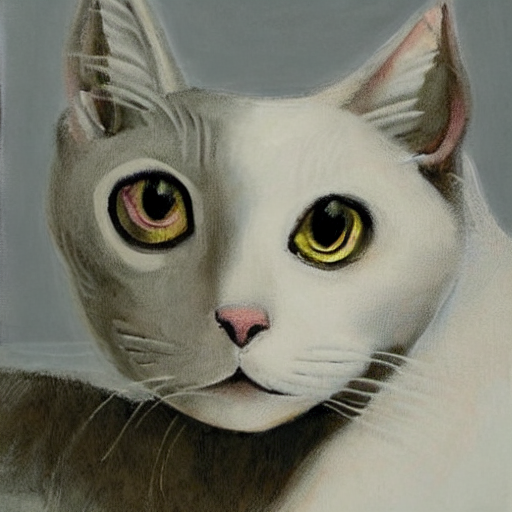

In [9]:
# Install dependencies
!pip install -q google-generativeai diffusers torch transformers Pillow IPython

import google.generativeai as genai
from diffusers import StableDiffusionPipeline
import torch
from PIL import Image
import io
import base64
from IPython.display import display, HTML

# Configure Gemini API
genai.configure(api_key=API_KEY)
model = genai.GenerativeModel("gemini-2.0-pro-exp")  # Or "gemini-1.5-flash" if needed

# Load Stable Diffusion with device fallback
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16 if device == "cuda" else torch.float32)
pipe = pipe.to(device)

# Prompt (example from your output)
prompt = "tell me about cats"

# Generate text with Gemini
response = model.generate_content(
    prompt,
    generation_config=genai.types.GenerationConfig(
        max_output_tokens=200,
        temperature=0.7,
        top_p=0.9
    )
)
text = response.text

# Simple Markdown-to-HTML converter
def markdown_to_html(text):
    # Replace bold (**text**) with <b>text</b>
    import re
    text = re.sub(r'\*\*(.*?)\*\*', r'<b>\1</b>', text)

    # Replace bullet points (* text) with <ul><li>text</li></ul>
    lines = text.split('\n')
    in_list = False
    html_lines = []
    for line in lines:
        if line.strip().startswith('* '):
            if not in_list:
                html_lines.append('<ul>')
                in_list = True
            line = line.strip()[2:]  # Remove '* '
            # Handle nested bold in bullet points
            line = re.sub(r'\*\*(.*?)\*\*', r'<b>\1</b>', line)
            html_lines.append(f'<li>{line}</li>')
        else:
            if in_list:
                html_lines.append('</ul>')
                in_list = False
            html_lines.append(line)
    if in_list:
        html_lines.append('</ul>')

    return '\n'.join(html_lines)

# Convert text to HTML
formatted_text = markdown_to_html(text)

# Create image prompt
image_prompt = f"{prompt.split('.')[0]}, detailed, realistic"

# Generate image with Stable Diffusion
print("Generating image...")
image = pipe(image_prompt, num_inference_steps=20, guidance_scale=7.5).images[0]

# Convert image to base64
buffered = io.BytesIO()
image.save(buffered, format="PNG")
image_base64 = base64.b64encode(buffered.getvalue()).decode("utf-8")

# Create styled HTML output
html_output = f"""
<style>
    h1 {{ font-family: Arial, sans-serif; }}
    h2 {{ font-family: Arial, sans-serif; }}
    p {{ font-family: Arial, sans-serif; line-height: 1.6; }}
    ul {{ margin-left: 20px; }}
    li {{ margin-bottom: 10px; }}
    img {{ border: 2px solid #ddd; border-radius: 5px; }}
</style>
<h1>Info App</h1>
<h2>Generated Text:</h2>
<p>{formatted_text}</p>
<h2>Generated Image:</h2>
<img src="data:image/png;base64,{image_base64}" alt="Generated Image" style="max-width: 500px;">
"""

# Display in Colab
display(HTML(html_output))